# Import necessary libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data of linux system usage

In [2]:
def load_data():
    try :
        df = pd.read_csv("data/sys_data.csv")
        return df
    except FileNotFoundError :
        print("Make sure you have file in this directory")
        return None
    except Exception as e :
        print(f"Error : {str(e)}")
        return None
df = load_data()

# Display first five row od dataset

In [3]:
df.head()

,timestamp,cpu_usage,memory_usage,disk_usage
0,2026-01-15 15:50:01,4.9,28.3,39.5
1,2026-01-15 15:51:01,3.0,28.5,39.5
2,2026-01-15 15:52:01,5.8,28.4,39.5
3,2026-01-15 15:53:01,30.7,30.3,39.5
4,2026-01-15 15:54:01,5.8,27.7,39.5


# Display last five row of the dataset

In [4]:
df.tail()

,timestamp,cpu_usage,memory_usage,disk_usage
685,2026-01-18 19:57:01,14.1,34.2,42.8
686,2026-01-18 19:58:01,3.5,33.8,42.8
687,2026-01-18 19:59:02,1.5,34.0,42.8
688,2026-01-18 20:00:01,58.8,42.7,42.8
689,2026-01-18 20:01:01,3.8,41.7,42.8


# checking the missing value in the dataset.

In [5]:
df.isnull().sum()

timestamp       0
cpu_usage       0
memory_usage    0
disk_usage      0
dtype: int64

# Checking the duplicated rows in the datasets.

In [6]:
df.duplicated().sum()

np.int64(0)

# Getting the information about the datasets.

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690 entries, 0 to 689
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   timestamp     690 non-null    object 
 1   cpu_usage     690 non-null    float64
 2   memory_usage  690 non-null    float64
 3   disk_usage    690 non-null    float64
dtypes: float64(3), object(1)
memory usage: 21.7+ KB


# Checking the shape(column,rows) of the datasets.

In [8]:
df.shape

(690, 4)

# Checking how many columns does datasets have.

In [9]:
df.columns

Index(['timestamp', 'cpu_usage', 'memory_usage', 'disk_usage'], dtype='object')

# previewing the basic statistics of the datasets.

In [10]:
df.describe()

,cpu_usage,memory_usage,disk_usage
count,690.000000,690.000000,690.000000
mean,11.105072,40.340725,41.978551
std,12.297389,15.255999,1.312064
min,0.000000,9.000000,39.500000
25%,3.000000,27.125000,42.100000
50%,7.100000,43.650000,42.700000
75%,14.400000,55.150000,42.800000
max,98.300000,68.600000,44.100000


# Checking the datatype of the columns timestamp to perform further actions.

In [11]:
df["timestamp"].dtype

dtype('O')

#  Converting the datatype of timestamp to datatime format. 

In [12]:
df["timestamp"] = pd.to_datetime(df["timestamp"], errors = "coerce")

In [13]:
df["timestamp"].dtype

dtype('<M8[ns]')

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690 entries, 0 to 689
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   timestamp     690 non-null    datetime64[ns]
 1   cpu_usage     690 non-null    float64       
 2   memory_usage  690 non-null    float64       
 3   disk_usage    690 non-null    float64       
dtypes: datetime64[ns](1), float64(3)
memory usage: 21.7 KB


In [15]:
df.columns

Index(['timestamp', 'cpu_usage', 'memory_usage', 'disk_usage'], dtype='object')

# Feature Engineering

#### Extracting time based feature from timestamp for better evaluation

In [16]:
def create_time_feature(df):
    df["year"] = df["timestamp"].dt.year
    df["month"] = df["timestamp"].dt.month
    df["day"] = df["timestamp"].dt.day
    df["hour"] = df["timestamp"].dt.hour
    df["minute"] = df["timestamp"].dt.minute
    df["day_of_week"] = df["timestamp"].dt.day_name()
    df["month_name"] = df["timestamp"].dt.month_name()
    df["day_of_year"] = df["timestamp"].dt.dayofyear
    return df

df = create_time_feature(df)

In [17]:
df.columns

Index(['timestamp', 'cpu_usage', 'memory_usage', 'disk_usage', 'year', 'month',
       'day', 'hour', 'minute', 'day_of_week', 'month_name', 'day_of_year'],
      dtype='object')

In [18]:
df.head()

,timestamp,cpu_usage,memory_usage,disk_usage,year,month,day,hour,minute,day_of_week,month_name,day_of_year
0,2026-01-15 15:50:01,4.9,28.3,39.5,2026,1,15,15,50,Thursday,January,15
1,2026-01-15 15:51:01,3.0,28.5,39.5,2026,1,15,15,51,Thursday,January,15
2,2026-01-15 15:52:01,5.8,28.4,39.5,2026,1,15,15,52,Thursday,January,15
3,2026-01-15 15:53:01,30.7,30.3,39.5,2026,1,15,15,53,Thursday,January,15
4,2026-01-15 15:54:01,5.8,27.7,39.5,2026,1,15,15,54,Thursday,January,15


In [19]:
df.tail()

,timestamp,cpu_usage,memory_usage,disk_usage,year,month,day,hour,minute,day_of_week,month_name,day_of_year
685,2026-01-18 19:57:01,14.1,34.2,42.8,2026,1,18,19,57,Sunday,January,18
686,2026-01-18 19:58:01,3.5,33.8,42.8,2026,1,18,19,58,Sunday,January,18
687,2026-01-18 19:59:02,1.5,34.0,42.8,2026,1,18,19,59,Sunday,January,18
688,2026-01-18 20:00:01,58.8,42.7,42.8,2026,1,18,20,0,Sunday,January,18
689,2026-01-18 20:01:01,3.8,41.7,42.8,2026,1,18,20,1,Sunday,January,18


In [20]:
df.describe()

,timestamp,cpu_usage,memory_usage,disk_usage,year,month,day,hour,minute,day_of_year
count,690,690.000000,690.000000,690.000000,690.0,690.0,690.000000,690.000000,690.000000,690.000000
mean,2026-01-16 23:51:00.997101312,11.105072,40.340725,41.978551,2026.0,1.0,16.259420,17.124638,29.952174,16.259420
min,2026-01-15 15:50:01,0.000000,9.000000,39.500000,2026.0,1.0,15.000000,14.000000,0.000000,15.000000
25%,2026-01-15 20:18:16,3.000000,27.125000,42.100000,2026.0,1.0,15.000000,15.000000,13.250000,15.000000
50%,2026-01-16 21:14:31,7.100000,43.650000,42.700000,2026.0,1.0,16.000000,17.000000,31.000000,16.000000
75%,2026-01-17 15:56:46,14.400000,55.150000,42.800000,2026.0,1.0,17.000000,19.000000,46.000000,17.000000
max,2026-01-18 20:01:01,98.300000,68.600000,44.100000,2026.0,1.0,18.000000,22.000000,59.000000,18.000000
std,NaN,12.297389,15.255999,1.312064,0.0,0.0,1.025484,2.305821,18.007635,1.025484


In [21]:
df['timestamp'].min(), df['timestamp'].max()

(Timestamp('2026-01-15 15:50:01'), Timestamp('2026-01-18 20:01:01'))

# Getting correlation of system usage

In [22]:
df.corr(numeric_only=True)

,cpu_usage,memory_usage,disk_usage,year,month,day,hour,minute,day_of_year
cpu_usage,1.000000,0.061276,0.052928,NaN,NaN,0.056762,0.029726,0.027953,0.056762
memory_usage,0.061276,1.000000,0.113437,NaN,NaN,0.109990,-0.492079,-0.027869,0.109990
disk_usage,0.052928,0.113437,1.000000,NaN,NaN,0.693748,0.035905,-0.048560,0.693748
year,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
month,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
day,0.056762,0.109990,0.693748,NaN,NaN,1.000000,-0.118040,-0.000820,1.000000
hour,0.029726,-0.492079,0.035905,NaN,NaN,-0.118040,1.000000,-0.145091,-0.118040
minute,0.027953,-0.027869,-0.048560,NaN,NaN,-0.000820,-0.145091,1.000000,-0.000820
day_of_year,0.056762,0.109990,0.693748,NaN,NaN,1.000000,-0.118040,-0.000820,1.000000


In [23]:
df_numeric = df.select_dtypes(include=['int64', 'float64'])

In [24]:
df_numeric

,cpu_usage,memory_usage,disk_usage
0,4.9,28.3,39.5
1,3.0,28.5,39.5
2,5.8,28.4,39.5
3,30.7,30.3,39.5
4,5.8,27.7,39.5
...,...,...,...
685,14.1,34.2,42.8
686,3.5,33.8,42.8
687,1.5,34.0,42.8
688,58.8,42.7,42.8


In [25]:
corr = df_numeric.corr()
corr

,cpu_usage,memory_usage,disk_usage
cpu_usage,1.000000,0.061276,0.052928
memory_usage,0.061276,1.000000,0.113437
disk_usage,0.052928,0.113437,1.000000


In [26]:
df.columns

Index(['timestamp', 'cpu_usage', 'memory_usage', 'disk_usage', 'year', 'month',
       'day', 'hour', 'minute', 'day_of_week', 'month_name', 'day_of_year'],
      dtype='object')

# Getting average of cpu_usage, memeory usage, disk usage by hour with the help of groupby functions

In [27]:
df.groupby("hour")[["cpu_usage", "memory_usage", "disk_usage"]].mean()

,cpu_usage,memory_usage,disk_usage
hour,,,
14,10.475000,42.127778,42.427778
15,10.655385,54.358462,42.444615
16,8.594697,39.412879,41.606061
17,12.084848,44.939394,41.100000
18,14.675385,37.009231,41.886154
19,14.997059,36.797059,41.627941
20,13.437500,26.665000,42.460000
21,6.546809,25.082979,42.600000
22,10.089189,25.148649,42.643243


# Getting average of cpu_usage, memeory usage, disk usage by day_of_week with the help of groupby functions

In [28]:
df.groupby("day_of_week") [["cpu_usage", "memory_usage", "disk_usage"]].mean()

,cpu_usage,memory_usage,disk_usage
day_of_week,,,
Friday,9.602110,39.741350,42.583544
Saturday,11.447771,51.697452,42.738217
Sunday,13.437736,33.301887,42.800000
Thursday,11.395263,35.631053,40.137895


# Getting average of memory usage by hour in saturday with groupby built-in function in pandas 

In [29]:
df[df['day_of_week'] == 'Saturday'].groupby('hour')['memory_usage'].mean()

hour
14    48.739394
15    59.755000
16    48.765217
18    51.212500
19    42.118182
20    18.400000
Name: memory_usage, dtype: float64

# Getting average of cpu usage and memory usage by day of week and hour with the help of groupby built-in functions in pandas

In [30]:
df.groupby(['day_of_week','hour'])[['cpu_usage','memory_usage']].mean()


cpu_usage  memory_usage
day_of_week hour                         
Friday      14     8.556410     36.533333
            15    11.391667     53.308333
            16    10.694444     49.740741
            21     6.546809     25.082979
            22    10.089189     25.148649
Saturday    14    12.742424     48.739394
            15    10.045000     59.755000
            16    12.039130     48.765217
            18    12.881250     51.212500
            19    12.304545     42.118182
            20     6.800000     18.400000
Sunday      16     0.888889     14.266667
            17    13.477083     40.660417
            18    16.316129     28.193548
            19    12.568750     30.718750
            20    31.300000     42.200000
Thursday    15     9.900000     28.280000
            16     5.915217     27.532609
            17    10.774510     48.966667
            18    13.444444     39.566667
            19    18.266667     36.136667
            20    12.985714     26.485714

In [31]:
df.groupby('day')[['memory_usage']].mean()

,memory_usage
day,
15,35.631053
16,39.741350
17,51.697452
18,33.301887


In [32]:
df['is_weekend'] = df['timestamp'].dt.dayofweek >= 5

In [33]:
df.head()

,timestamp,cpu_usage,memory_usage,disk_usage,year,month,day,hour,minute,day_of_week,month_name,day_of_year,is_weekend
0,2026-01-15 15:50:01,4.9,28.3,39.5,2026,1,15,15,50,Thursday,January,15,False
1,2026-01-15 15:51:01,3.0,28.5,39.5,2026,1,15,15,51,Thursday,January,15,False
2,2026-01-15 15:52:01,5.8,28.4,39.5,2026,1,15,15,52,Thursday,January,15,False
3,2026-01-15 15:53:01,30.7,30.3,39.5,2026,1,15,15,53,Thursday,January,15,False
4,2026-01-15 15:54:01,5.8,27.7,39.5,2026,1,15,15,54,Thursday,January,15,False


In [34]:
df.tail()

,timestamp,cpu_usage,memory_usage,disk_usage,year,month,day,hour,minute,day_of_week,month_name,day_of_year,is_weekend
685,2026-01-18 19:57:01,14.1,34.2,42.8,2026,1,18,19,57,Sunday,January,18,True
686,2026-01-18 19:58:01,3.5,33.8,42.8,2026,1,18,19,58,Sunday,January,18,True
687,2026-01-18 19:59:02,1.5,34.0,42.8,2026,1,18,19,59,Sunday,January,18,True
688,2026-01-18 20:00:01,58.8,42.7,42.8,2026,1,18,20,0,Sunday,January,18,True
689,2026-01-18 20:01:01,3.8,41.7,42.8,2026,1,18,20,1,Sunday,January,18,True


In [35]:
df['cpu_roll_mean_5'] = df['cpu_usage'].rolling(window=5).mean()

In [36]:
df["cpu_roll_mean_5"]

0        NaN
1        NaN
2        NaN
3        NaN
4      10.04
       ...  
685    16.06
686    13.52
687    10.62
688    18.54
689    16.34
Name: cpu_roll_mean_5, Length: 690, dtype: float64

In [37]:
df['cpu_roll_std_5'] = df['cpu_usage'].rolling(window=5).std()

In [38]:
df["cpu_roll_std_5"]

0            NaN
1            NaN
2            NaN
3            NaN
4      11.605731
         ...    
685     1.956528
686     5.932706
687     7.698506
688    23.297704
689    24.239493
Name: cpu_roll_std_5, Length: 690, dtype: float64

In [39]:
df.set_index("timestamp", inplace=True)
df['cpu_roll_30min'] = df['cpu_usage'].rolling('30min').mean()

In [40]:
df["cpu_roll_30min"]

timestamp
2026-01-15 15:50:01     4.900000
2026-01-15 15:51:01     3.950000
2026-01-15 15:52:01     4.566667
2026-01-15 15:53:01    11.100000
2026-01-15 15:54:01    10.040000
                         ...    
2026-01-18 19:57:01    14.007143
2026-01-18 19:58:01    13.306667
2026-01-18 19:59:02    12.568750
2026-01-18 20:00:01    15.288235
2026-01-18 20:01:01    14.650000
Name: cpu_roll_30min, Length: 690, dtype: float64

In [41]:
df.columns

Index(['cpu_usage', 'memory_usage', 'disk_usage', 'year', 'month', 'day',
       'hour', 'minute', 'day_of_week', 'month_name', 'day_of_year',
       'is_weekend', 'cpu_roll_mean_5', 'cpu_roll_std_5', 'cpu_roll_30min'],
      dtype='object')

In [42]:
df.head()

,cpu_usage,memory_usage,disk_usage,year,month,day,hour,minute,day_of_week,month_name,day_of_year,is_weekend,cpu_roll_mean_5,cpu_roll_std_5,cpu_roll_30min
timestamp,,,,,,,,,,,,,,,
2026-01-15 15:50:01,4.9,28.3,39.5,2026,1,15,15,50,Thursday,January,15,False,NaN,NaN,4.900000
2026-01-15 15:51:01,3.0,28.5,39.5,2026,1,15,15,51,Thursday,January,15,False,NaN,NaN,3.950000
2026-01-15 15:52:01,5.8,28.4,39.5,2026,1,15,15,52,Thursday,January,15,False,NaN,NaN,4.566667
2026-01-15 15:53:01,30.7,30.3,39.5,2026,1,15,15,53,Thursday,January,15,False,NaN,NaN,11.100000
2026-01-15 15:54:01,5.8,27.7,39.5,2026,1,15,15,54,Thursday,January,15,False,10.04,11.605731,10.040000


In [43]:
df.columns

Index(['cpu_usage', 'memory_usage', 'disk_usage', 'year', 'month', 'day',
       'hour', 'minute', 'day_of_week', 'month_name', 'day_of_year',
       'is_weekend', 'cpu_roll_mean_5', 'cpu_roll_std_5', 'cpu_roll_30min'],
      dtype='object')

In [44]:
df = df.drop(columns = ["year", "month", "day", "day_of_week", "month_name", "day_of_year"])

In [45]:
df.head()

,cpu_usage,memory_usage,disk_usage,hour,minute,is_weekend,cpu_roll_mean_5,cpu_roll_std_5,cpu_roll_30min
timestamp,,,,,,,,,
2026-01-15 15:50:01,4.9,28.3,39.5,15,50,False,NaN,NaN,4.900000
2026-01-15 15:51:01,3.0,28.5,39.5,15,51,False,NaN,NaN,3.950000
2026-01-15 15:52:01,5.8,28.4,39.5,15,52,False,NaN,NaN,4.566667
2026-01-15 15:53:01,30.7,30.3,39.5,15,53,False,NaN,NaN,11.100000
2026-01-15 15:54:01,5.8,27.7,39.5,15,54,False,10.04,11.605731,10.040000


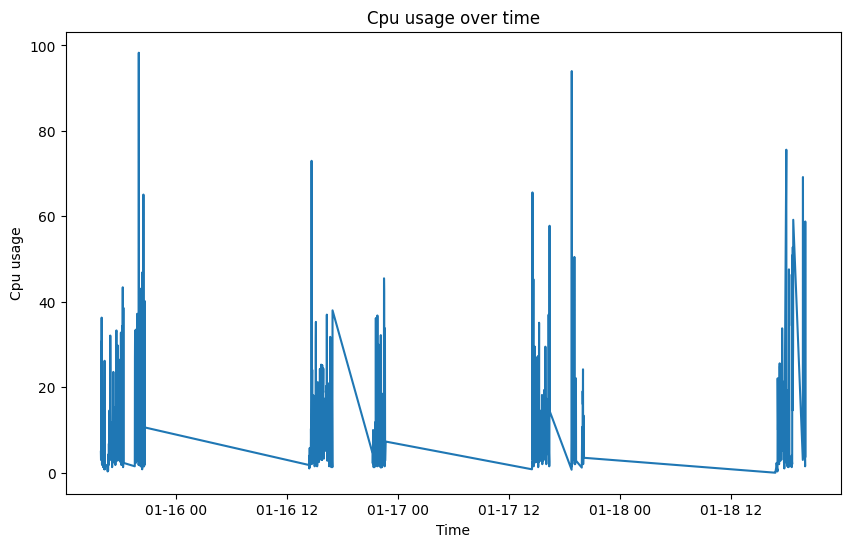

In [46]:
#plot cpu usage over time 
plt.figure(figsize = (10,6))
plt.plot(df.index, df["cpu_usage"], label = "Cpu usage")
plt.xlabel("Time")
plt.ylabel("Cpu usage")
plt.title("Cpu usage over time")
plt.savefig("images/Cpu_usage_over_time_plot.png", dpi=300)
plt.show()

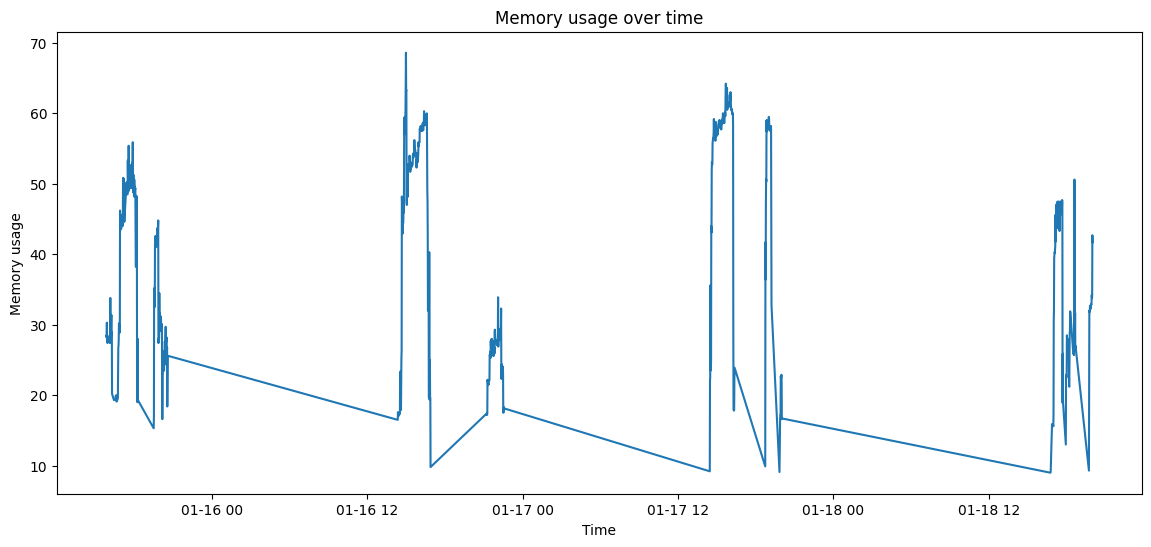

In [47]:
#plot memory usage overtime
plt.figure(figsize = (14,6))
plt.plot(df.index, df["memory_usage"], label = "Memory usage")
plt.xlabel("Time")
plt.ylabel("Memory usage")
plt.title("Memory usage over time")
plt.savefig("images/Memory_usage_over_time_plot.png")
plt.show()

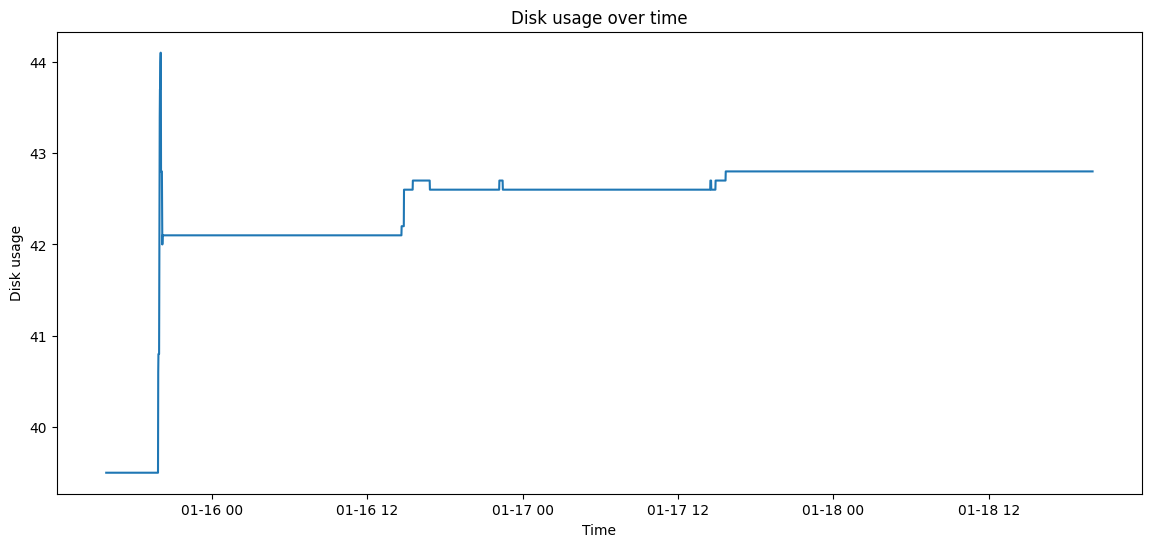

In [48]:
#plot disk usage over time 
plt.figure(figsize = (14,6))
plt.plot(df.index, df["disk_usage"], label= "Disk usage")
plt.xlabel("Time")
plt.ylabel("Disk usage")
plt.title("Disk usage over time")
plt.savefig("images/disk_usage_over_time_plot.png")
plt.show()

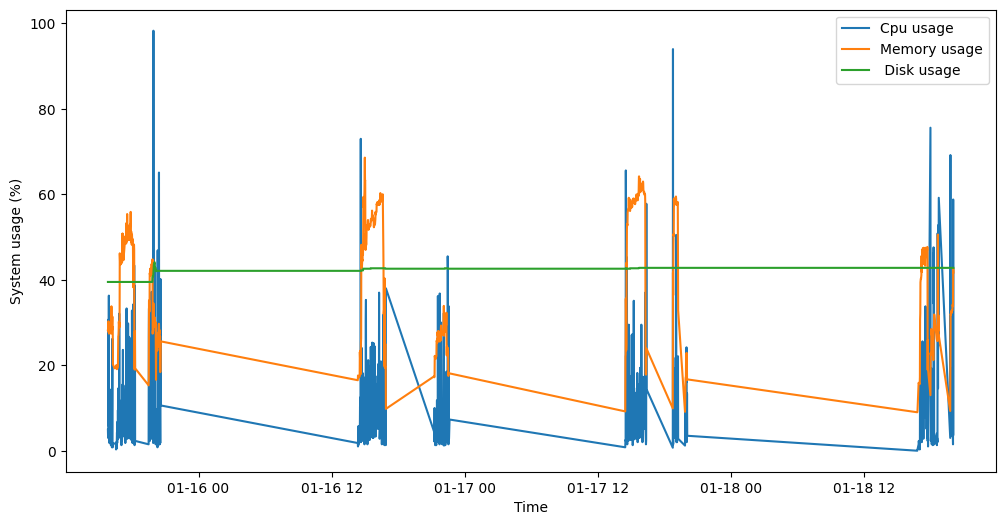

In [49]:
# plot system usage over time 
plt.figure(figsize = (12,6))
plt.plot(df.index, df["cpu_usage"], label = "Cpu usage")
plt.plot(df.index, df["memory_usage"], label = "Memory usage")
plt.plot(df.index, df["disk_usage"], label = " Disk usage")
plt.xlabel("Time")
plt.ylabel("System usage (%)")
plt.legend()
plt.savefig("images/system_usage_over_time_plot.png", dpi = 300)
plt.show()

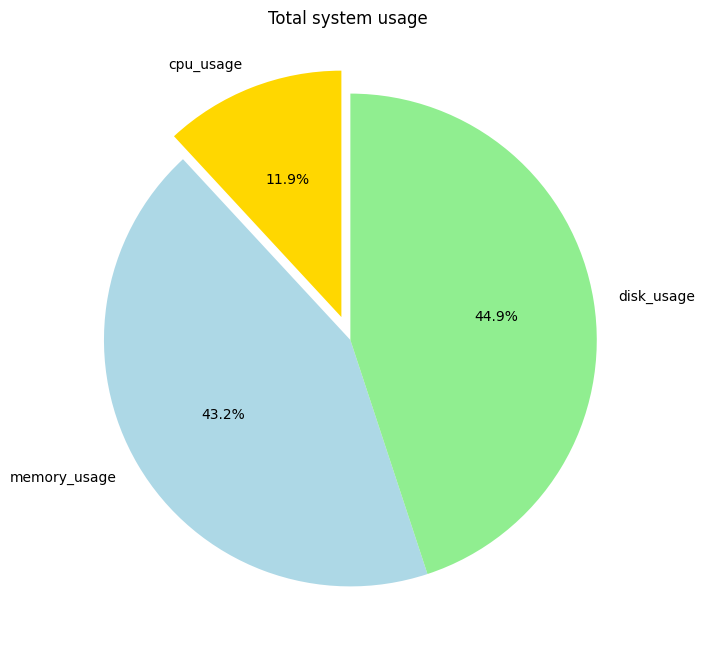

In [50]:
# pie chart plot of system usage 
usage_total = df[["cpu_usage", "memory_usage", "disk_usage"]].sum()

plt.figure(figsize = (8,8))
plt.pie(
    usage_total,
    labels = usage_total.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=['gold', 'lightblue', 'lightgreen'],
    explode=(0.1,0,0)
)
plt.title("Total system usage ")
plt.savefig("images/Total_system_usage_piechart.png")
plt.show()

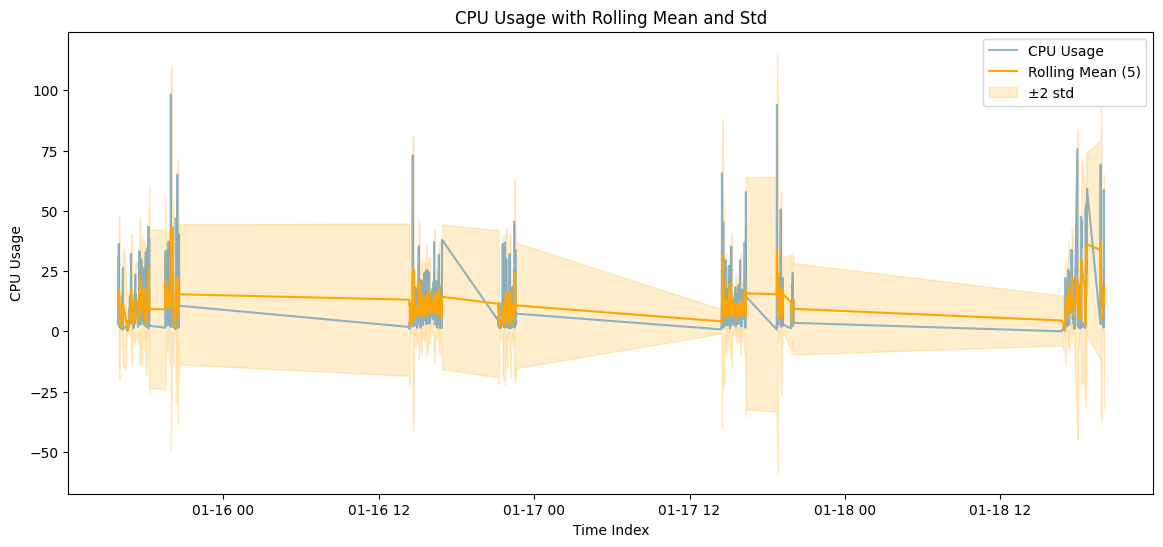

In [51]:
plt.figure(figsize=(14,6))
plt.plot(df['cpu_usage'], label='CPU Usage', alpha=0.5)
plt.plot(df['cpu_roll_mean_5'], label='Rolling Mean (5)', color='orange')
plt.fill_between(df.index, 
                 df['cpu_roll_mean_5'] - 2*df['cpu_roll_std_5'], 
                 df['cpu_roll_mean_5'] + 2*df['cpu_roll_std_5'],
                 color='orange', alpha=0.2, label='±2 std')
plt.xlabel("Time Index")
plt.ylabel("CPU Usage")
plt.title("CPU Usage with Rolling Mean and Std")
plt.legend()
plt.savefig("images/cpu_usage_with_rolling_mean_std.png", dpi = 300)
plt.show()

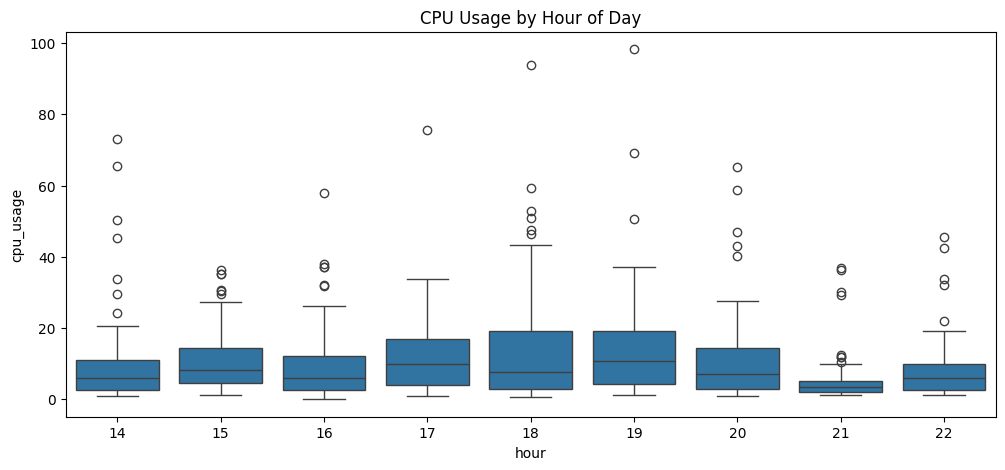

In [52]:
# CPU usage by hour
plt.figure(figsize=(12,5))
sns.boxplot(x='hour', y='cpu_usage', data=df)
plt.title("CPU Usage by Hour of Day")
plt.savefig("images/cpu_usage_by_hourofday.png", dpi = 300)
plt.show()

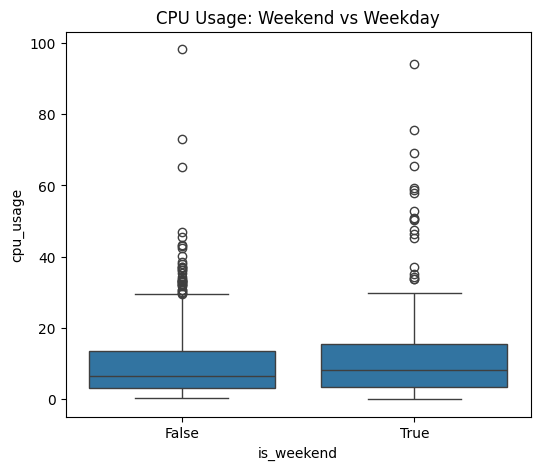

In [53]:
# cpu usage by weekend vs weekday
plt.figure(figsize=(6,5))
sns.boxplot(x='is_weekend', y='cpu_usage', data=df)
plt.title("CPU Usage: Weekend vs Weekday")
plt.savefig("images/cpu_usage_weekend_vs_weekday.png", dpi = 300)
plt.show()

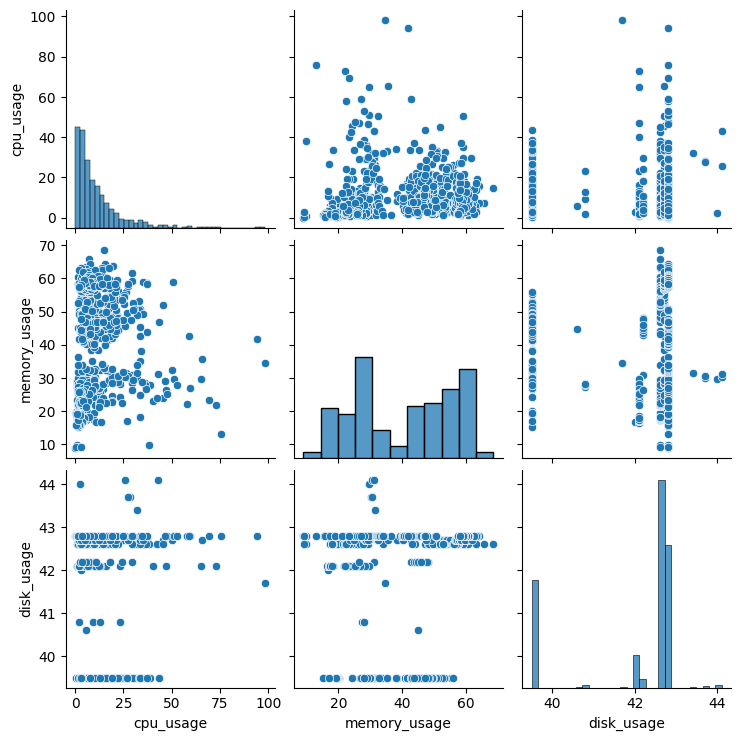

In [54]:
sns.pairplot(df[['cpu_usage', 'memory_usage', 'disk_usage']])
plt.savefig("images/pairplot_cpu_memory_disk_usage.png", dpi = 300)
plt.show()

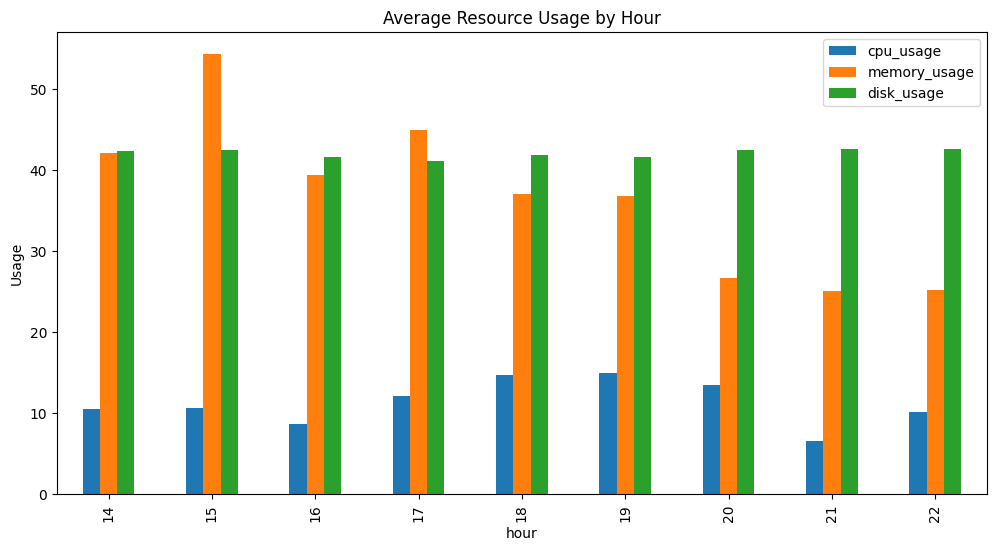

In [55]:
hourly_avg = df.groupby('hour')[['cpu_usage','memory_usage','disk_usage']].mean()
hourly_avg.plot(kind='bar', figsize=(12,6))
plt.title("Average Resource Usage by Hour")
plt.ylabel("Usage")
plt.savefig("images/average_resources_usage_by_hour.png", dpi = 300)
plt.show()

In [56]:
# saving clean dataset for machine learning model
df.to_csv("data/processed_dataset.csv", index = False)